# U-Nesting Playground

Explore the `Board2D` API interactively: load parts, nest them, visualise results, and try the RL-style incremental placement interface.

In [1]:
import sys, json, math, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon

# Make sure the venv's u_nesting is on the path
sys.path.insert(0, str(Path("crates/python/python").resolve()))

import u_nesting

print("u_nesting version:", u_nesting.version())
print("Available strategies:", u_nesting.available_strategies())

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
u_nesting version: 0.3.1
Available strategies: ['blf', 'nfp', 'ga', 'brkga', 'sa', 'ep']


## 1. Load the dataset

In [2]:
DATASET = Path("../repos/sparrow/data/input/aligner_library.json")

with open(DATASET) as f:
    data = json.load(f)

print(f"Dataset: {data['name']}")
print(f"Strip height: {data['strip_height']}")
print(f"Number of part types: {len(data['items'])}")

# Quick size overview
areas = []
for item in data['items']:
    verts = item['shape']['data']
    n = len(verts)
    area = abs(sum(verts[i][0]*verts[(i+1)%n][1] - verts[(i+1)%n][0]*verts[i][1]
                   for i in range(n))) / 2
    areas.append(area)

print(f"\nPart area — min: {min(areas):.1f}  max: {max(areas):.1f}  mean: {sum(areas)/len(areas):.1f}")

Dataset: aligner_library
Strip height: 100.0
Number of part types: 100

Part area — min: 116.7  max: 586.8  mean: 327.4


## 2. Sample parts & create the board

In [3]:
# ── Parameters ────────────────────────────────────────────────────────────────
N_PARTS    = 25              # how many parts to sample
SEED       = 42              # random seed (None = random)
BOARD_W    = 100.0
BOARD_H    = 100.0
STRATEGY   = "nfp"           # "nfp" | "blf" | "ga" | "brkga" | "sa"
ROTATIONS  = [0, 90, 180, 270]   # degrees — or None to use dataset default ([0.0])
# ──────────────────────────────────────────────────────────────────────────────

rng = random.Random(SEED)
sampled = rng.sample(data["items"], N_PARTS)

parts = [
    {
        "id": item["label"],
        "polygon": item["shape"]["data"],
        "rotations": ROTATIONS if ROTATIONS is not None else item["allowed_orientations"],
    }
    for item in sampled
]

BOUNDARY = {"width": BOARD_W, "height": BOARD_H}
CONFIG   = {"strategy": STRATEGY, "spacing": 0.0}

board = u_nesting.Board2D(boundary=BOUNDARY, geometries=parts, config=CONFIG)
print(f"Board created — {len(parts)} parts loaded")
print(f"Rotations: {ROTATIONS}")

Board created — 25 parts loaded
Rotations: [0, 90, 180, 270]


## 3. Interactive step-by-step placement

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── State ─────────────────────────────────────────────────────────────────────
board.reset()
_step = {"i": 0}   # next part index
cmap  = plt.get_cmap("tab20")

# ── Render helpers ─────────────────────────────────────────────────────────────
def _draw_board(ax):
    ax.add_patch(plt.Rectangle((0, 0), BOARD_W, BOARD_H,
                                linewidth=2, edgecolor="black", facecolor="#f5f5f5"))
    for j, (verts, pl) in enumerate(zip(board.placed_polygons(), board.placements())):
        color = cmap(j % 20)
        rot_deg = round(math.degrees(pl["rotation"]), 1)
        ax.add_patch(MplPolygon(verts, closed=True,
                                facecolor=(*color[:3], 0.6),
                                edgecolor="black", linewidth=0.8))
    ax.set_xlim(-2, BOARD_W + 2); ax.set_ylim(-2, BOARD_H + 2)
    ax.set_aspect("equal"); ax.axis("off")

out = widgets.Output()

def refresh():
    i = _step["i"]
    with out:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                                 gridspec_kw={"width_ratios": [1, 1]})

        # Left: board
        _draw_board(axes[0])
        n_placed = board.placed_count()
        util     = board.utilization()
        next_id  = parts[i]["id"] if i < len(parts) else "—"
        axes[0].set_title(
            f"Step {i}/{len(parts)}  |  placed: {n_placed}  |  util: {util:.1%}\n"
            f"Next: {next_id}",
            fontsize=10
        )

        # Right: part canvas of the next part (or blank if done)
        if i < len(parts):
            canvas = board.part_canvas(parts[i]["id"])
            axes[1].imshow(canvas, cmap="gray", vmin=0, vmax=1, origin="lower")
            rot_str = str(parts[i]["rotations"])
            axes[1].set_title(f"Next part: {parts[i]['id']}\nallowed rotations: {rot_str}", fontsize=10)
        else:
            axes[1].text(0.5, 0.5, "All parts processed", ha="center", va="center",
                         transform=axes[1].transAxes, fontsize=12)
            axes[1].set_title("Done", fontsize=10)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

        # Log of last placements
        placed = board.placements()
        if placed:
            last = placed[-1]
            rot_deg = round(math.degrees(last["rotation"]), 1)
            print(f"Last placed: {last['geometry_id']}  "
                  f"pos=({last['position'][0]:.2f}, {last['position'][1]:.2f})  "
                  f"rot={rot_deg}°")

def on_place(_):
    i = _step["i"]
    if i >= len(parts):
        return
    board.place(parts[i]["id"])
    _step["i"] += 1
    refresh()

def on_undo(_):
    if board.placed_count() == 0:
        return
    board.undo()
    _step["i"] = max(0, _step["i"] - 1)
    refresh()

def on_reset(_):
    board.reset()
    _step["i"] = 0
    refresh()

btn_place = widgets.Button(description="Place next", button_style="success",
                           layout=widgets.Layout(width="140px"))
btn_undo  = widgets.Button(description="Undo",       button_style="warning",
                           layout=widgets.Layout(width="100px"))
btn_reset = widgets.Button(description="Reset",      button_style="danger",
                           layout=widgets.Layout(width="100px"))

btn_place.on_click(on_place)
btn_undo.on_click(on_undo)
btn_reset.on_click(on_reset)

display(widgets.HBox([btn_place, btn_undo, btn_reset]), out)
refresh()

Output()

## 4. Visualise the nest

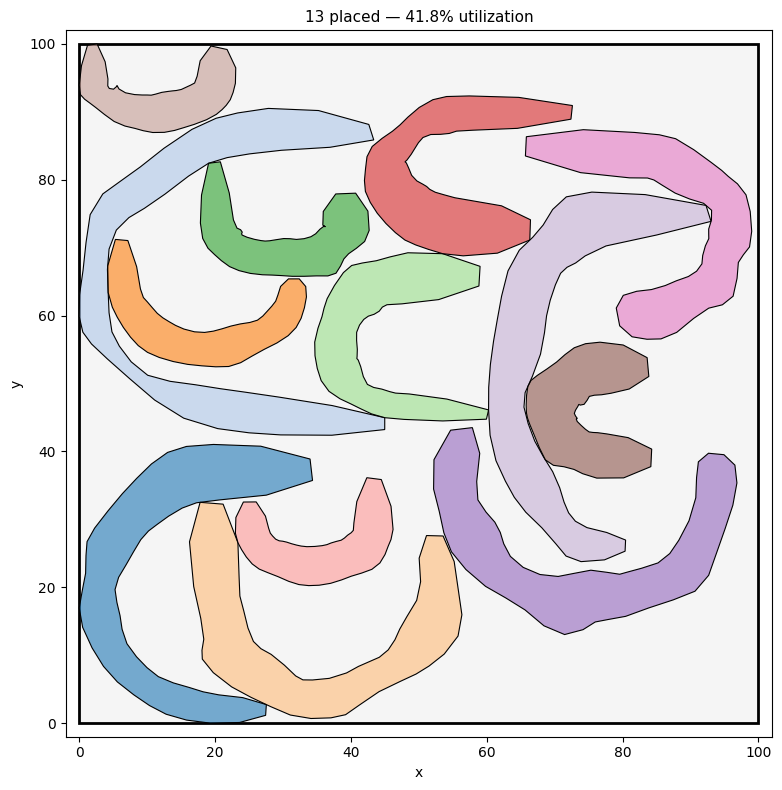

In [6]:
def plot_board(board, boundary, title=None):
    w, h = boundary["width"], boundary["height"]
    cmap = plt.get_cmap("tab20")
    placed = board.placements()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.add_patch(plt.Rectangle((0, 0), w, h, linewidth=2,
                                edgecolor="black", facecolor="#f5f5f5"))

    color_map = {p["geometry_id"]: cmap(i % 20)
                 for i, p in enumerate(placed)}

    for poly_verts, placement in zip(board.placed_polygons(), placed):
        color = color_map[placement["geometry_id"]]
        patch = MplPolygon(poly_verts, closed=True,
                           facecolor=(*color[:3], 0.6),
                           edgecolor="black", linewidth=0.8)
        ax.add_patch(patch)

    n_placed = board.placed_count()
    util = board.utilization()
    ax.set_title(title or f"{n_placed} placed — {util:.1%} utilization", fontsize=11)
    ax.set_xlim(-2, w + 2)
    ax.set_ylim(-2, h + 2)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()

plot_board(board, BOUNDARY)

## 5. SDF images — board & individual placements

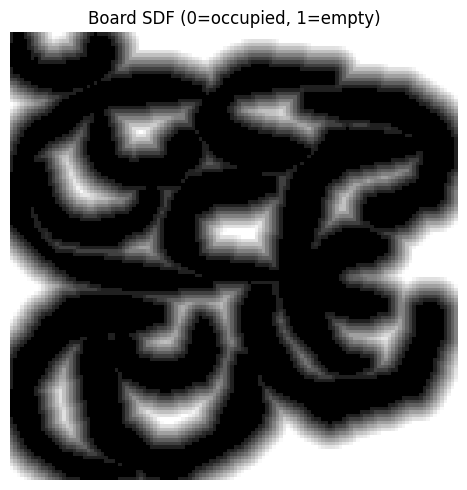

In [7]:
# Full board SDF
board_img = board.board_image()   # (1, 128, 128) float32

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(board_img[0], cmap="gray", vmin=0, vmax=1, origin="lower")
ax.set_title("Board SDF (0=occupied, 1=empty)")
ax.axis("off")
plt.tight_layout()
plt.show()

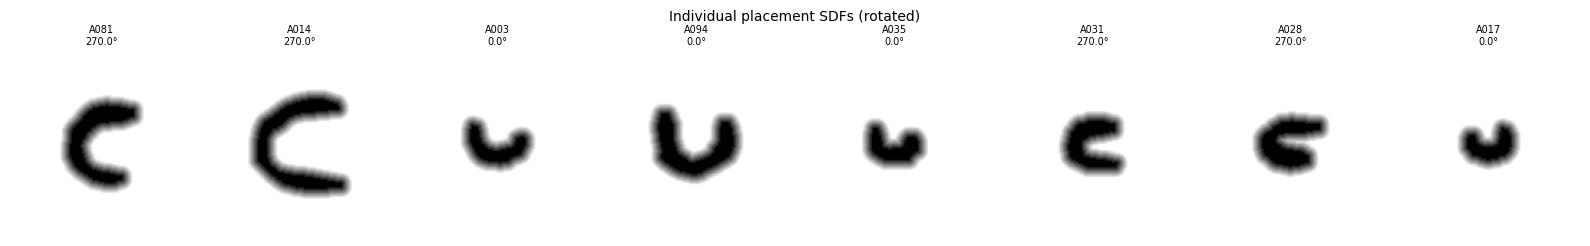

In [8]:
# First 8 individual placement SDFs (rotation clearly visible — centered canvas)
placements = board.placements()
n_show = min(8, len(placements))
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
if n_show == 1:
    axes = [axes]
for ax, placement in zip(axes, placements[:n_show]):
    img = board.render_placement(placement)
    rot_deg = round(math.degrees(placement["rotation"]), 1)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, origin="lower")
    ax.set_title(f"{placement['geometry_id']}\n{rot_deg}°", fontsize=7)
    ax.axis("off")
plt.suptitle("Individual placement SDFs (rotated)", fontsize=10)
plt.tight_layout()
plt.show()

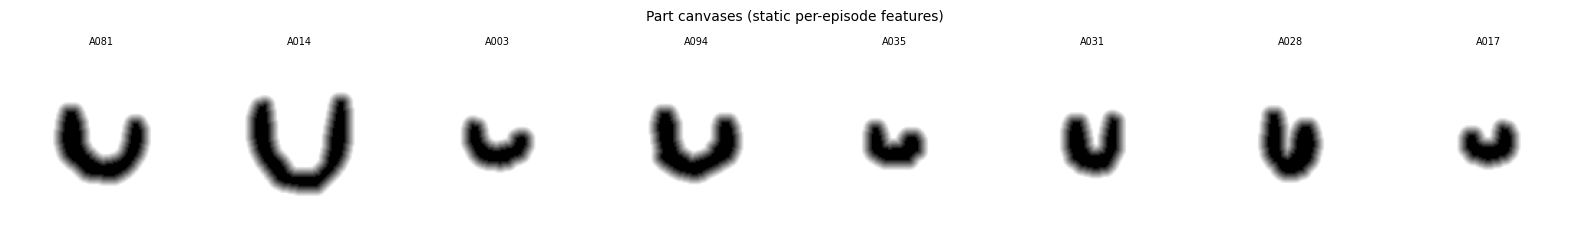

In [9]:
# Per-part canvases (centered, no board context) — RL static features
n_show = min(8, len(parts))
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
for ax, p in zip(axes, parts[:n_show]):
    canvas = board.part_canvas(p["id"])
    ax.imshow(canvas, cmap="gray", vmin=0, vmax=1, origin="lower")
    ax.set_title(p["id"], fontsize=7)
    ax.axis("off")
plt.suptitle("Part canvases (static per-episode features)", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Snapshot / restore — RL rollout pattern

After 3 parts: 3 placed, 11.2% utilization
Snapshot saved (3 entries)

Branch A (+A094): 4 placed, 15.5%


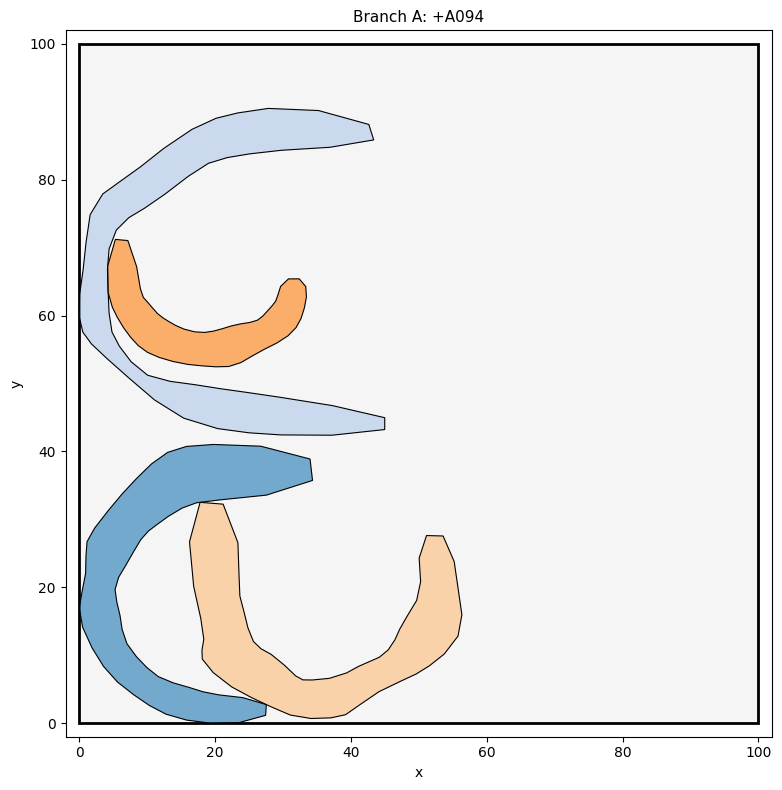

Restored: 3 placed
Branch B (+A035): 4 placed, 13.0%


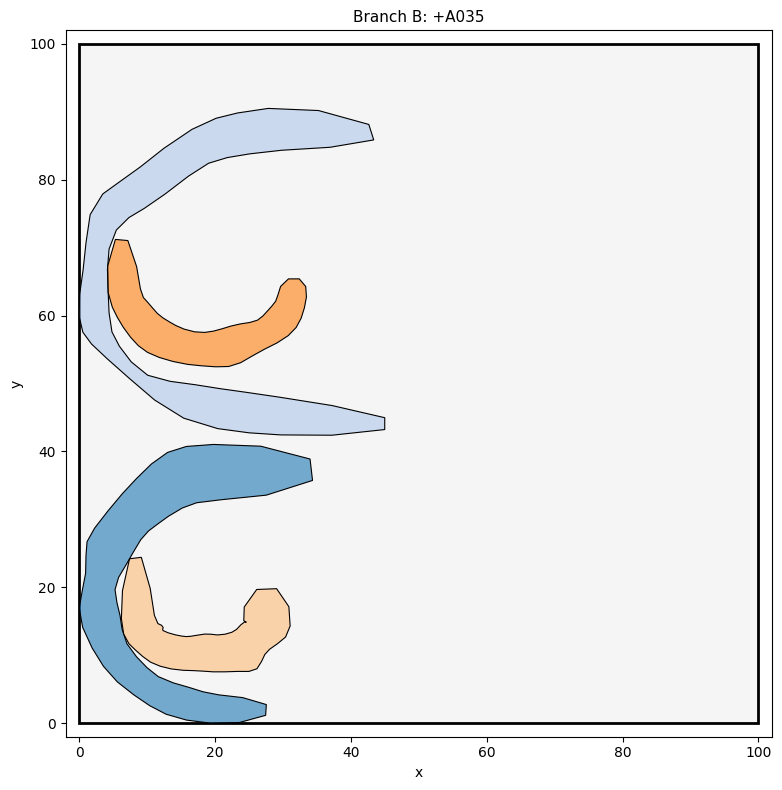

In [10]:
# Place the first 3 parts, then branch
board.reset()
for p in parts[:3]:
    board.place(p["id"])

print(f"After 3 parts: {board.placed_count()} placed, {board.utilization():.1%} utilization")

snap = board.snapshot()
print(f"Snapshot saved ({len(snap)} entries)")

# Branch A: place part 4
board.place(parts[3]["id"])
print(f"\nBranch A (+{parts[3]['id']}): {board.placed_count()} placed, {board.utilization():.1%}")
plot_board(board, BOUNDARY, title=f"Branch A: +{parts[3]['id']}")

# Restore and try branch B
board.restore(snap)
print(f"Restored: {board.placed_count()} placed")
board.place(parts[4]["id"])
print(f"Branch B (+{parts[4]['id']}): {board.placed_count()} placed, {board.utilization():.1%}")
plot_board(board, BOUNDARY, title=f"Branch B: +{parts[4]['id']}")

## 8. Compare placement orderings

as sampled            placed=14/25  util=44.3%
largest first         placed=14/25  util=47.0%
smallest first        placed=16/25  util=43.5%
shuffled              placed=16/25  util=50.1%
largest first (final)  placed=14/25  util=47.0%


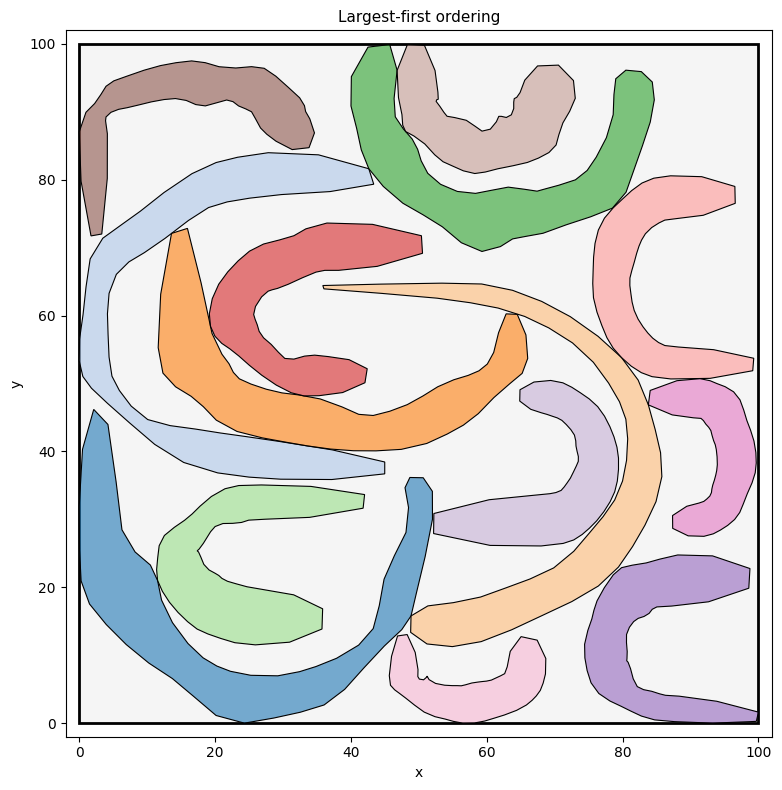

In [11]:
def polygon_area(verts):
    n = len(verts)
    return abs(sum(verts[i][0]*verts[(i+1)%n][1] - verts[(i+1)%n][0]*verts[i][1]
                   for i in range(n))) / 2

def run_ordering(board, ordering, label):
    board.reset()
    placed = sum(1 for p in ordering if board.place(p["id"]) is not None)
    util = board.utilization()
    print(f"{label:20s}  placed={placed}/{len(ordering)}  util={util:.1%}")
    return util

# Three orderings to compare
as_sampled  = parts
largest_first  = sorted(parts, key=lambda p: polygon_area(p["polygon"]), reverse=True)
smallest_first = sorted(parts, key=lambda p: polygon_area(p["polygon"]))
shuffled    = parts[:]
random.Random(99).shuffle(shuffled)

run_ordering(board, as_sampled,     "as sampled")
run_ordering(board, largest_first,  "largest first")
run_ordering(board, smallest_first, "smallest first")
run_ordering(board, shuffled,       "shuffled")

# Leave board in largest-first state for subsequent cells
run_ordering(board, largest_first, "largest first (final)")
plot_board(board, BOUNDARY, title="Largest-first ordering")

## 9. Board SDF animation — watch it fill up

In [ ]:
board.reset()
snapshots = [board.board_image()[0].copy()]  # empty board

for p in largest_first:
    r = board.place(p["id"])
    if r:
        snapshots.append(board.board_image()[0].copy())

n_snaps = len(snapshots)
n_cols  = min(8, n_snaps)
n_rows  = math.ceil(n_snaps / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows))
axes = axes.flatten()

for i, (img, ax) in enumerate(zip(snapshots, axes)):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, origin="lower")
    ax.set_title(f"step {i}", fontsize=7)
    ax.axis("off")

for ax in axes[n_snaps:]:
    ax.axis("off")

plt.suptitle("Board SDF after each placement", fontsize=11)
plt.tight_layout()
plt.show()